In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ctxbandit import PolicyInferenceDifference

In [ ]:
num_arms = 10 
context_dim = 12

size_inference = 1024
seed_inference = 11235813

size_learning_baseline = 256
seed_learning_baseline = 31415926

scale_se, power_ub, num_arms_top = 1, 2, 3
policy_param_baseline = scale_se, power_ub, num_arms_top

size_learning_new = 1024
seed_learning_new = 31415926

scale_se, power_ub, num_arms_top = 1, 1, 1
policy_param_new = scale_se, power_ub, num_arms_top

inference = PolicyInferenceDifference(
    num_arms, context_dim, 
    size_inference, seed_inference, 
    size_learning_baseline, seed_learning_baseline, policy_param_baseline, 
    size_learning_new, seed_learning_new, policy_param_new, 
)

### Compute Policy Value by MC Integration

In [ ]:
inference.compute_policy_value_by_mc_integration(
    repeat=100, size_per_repeat=1000,    # use a small MC sample size for demonstration
    seed=31415926, verbose=True, 
)

Policy value by Monte Carlo integration
    0.07636457 (difference)
    0.7546347 (baseline)
    0.8309993 (new)
    0.838117 (oracle)
Parameters
    MC sample size: 100,000 (100 repetitions of subsample size 1,000 each)
    Random seed: 31415926
Runtime
    0:00:01.7



In [ ]:
print(inference.mc_result)

policy_value_vector: (0.7546347, 0.8309993)
policy_value_difference: 0.07636457
policy_value_baseline: 0.7546347
policy_value_new: 0.8309993
policy_value_oracle: 0.838117
runtime: 1.719039
parameters:
    mc_sample_size: 100,000
    repeat: 100
    size_per_repeat: 1,000
    seed: 31,415,926


### Compute MLE

In [ ]:
size = 16
inference.compute_mle(size)
mle_result = inference.mle_result_by_size[size]
print(mle_result)

joint:
    mle: [0.7660109, 0.9527439]
    unique: False
    mle_observed: [0.6838969, 0.9054878]
    interval: ([0.6838969, 0.9054878], [0.848125, 1])
    region: ([0.6838969, 0.9054878], [0.7784091, 1], [0.848125, 1], [0.7536128, 0.9054878])
difference:
    mle: 0.186733
    unique: False
    mle_observed: 0.2215909
    interval: (0.151875, 0.2215909)
max_log_elr: -0.4968843
beta_star: [-0.1111111, -1.407537e-10]
unobserved_extreme: ([0, 10], [10, 0], [10, 10])
unobserved_extreme_with_weight: ([10, 0], [10, 10])
unobserved_extreme_with_weight_excluding_0: ([10, 0], [10, 10])
solver_index: 0
runtime: 0.007816276


### Importance Dataset Used for Inference

In [ ]:
importance_dataset = inference.importance_dataset_by_size[size]
print(importance_dataset, '\n')

print(
    np.column_stack((
        importance_dataset.c, 
        importance_dataset.ww, 
        importance_dataset.r, 
    ))
)

c: ndarray of shape (4,)
ww: ndarray of shape (4, 2)
r: ndarray of shape (4,) 

[[13.          0.          0.          0.        ]
 [ 1.          3.77358491  0.          1.        ]
 [ 1.          2.12598425  0.          0.        ]
 [ 1.          3.78787879 10.          1.        ]]


### Compute Wilks' Interval

In [ ]:
inference.compute_wilks_interval(size, level=0.90)
inference.compute_wilks_interval(size, level=0.95)
wilks_result = inference.wilks_result_by_size[size]
print(wilks_result)

wilks_95:
    interval: (-0.6394542, 0.7582097)
    cover: True
    position: 0
    width: 1.397664
    elr_cutoff: 0.08913406
    level: 0.95
    solver_index: (0, 0)
    runtime: 0.01392975
wilks_90:
    interval: (-0.4841433, 0.6802648)
    cover: True
    position: 0
    width: 1.164408
    elr_cutoff: 0.1572913
    level: 0.9
    solver_index: (0, 0)
    runtime: 0.01629187
wilks_others: None


### Compute Empirical Likelihood Ratio over Grid

In [ ]:
inference.compute_elr_over_grid(size, num_points=1000, verbose=True)
grid_result = inference.grid_result_by_size[size]

Completed computing the empirical likelihood ratio over a grid
    Parameters
        Importance dataset size: 16
        Number of grid points: 1,000
        Wilks level for adaptive support: 0.9999
        Parallel computing: True
            num_processes: 4
            maxtasksperchild: None
            chunksize: 63
            num_chunks: 16
    Runtime
        wilks_bound: 0:00:00
        elr_on_grid: 0:00:00.3
        total:       0:00:00.3



In [ ]:
print(grid_result)

grid: ndarray of shape (1000,)
elr_on_grid: ndarray of shape (1000,)
solver_index_on_grid: ndarray of shape (1000,)
step_size: 0.001970591
adaptive_support:
    bound: (-0.9845655, 0.9860255)
    width: 1.970591
    elr_cutoff: 0.0003142766
    wilks_level: 0.9999
    solver_index: (0, 0)
    runtime: 0.01420136
runtime:
    wilks_bound: 0.01420136
    elr_on_grid: 0.2807302
    total: 0.2949316


### Compute HPD Interval

In [ ]:
inference.compute_hpd_interval(size, level=0.90)
inference.compute_hpd_interval(size, level=0.95)
hpd_result = inference.hpd_result_by_size[size]
print(hpd_result)

hpd_95:
    interval: (-0.5943885, 0.7345086)
    cover: True
    position: 0
    width: 1.328897
    elr_cutoff: 0.1074039
    level: 0.95
    runtime: 0.0002556094
hpd_90:
    interval: (-0.465435, 0.670731)
    cover: True
    position: 0
    width: 1.136166
    elr_cutoff: 0.1665879
    level: 0.9
    runtime: 0.0002791588
hpd_others: None


### Plot

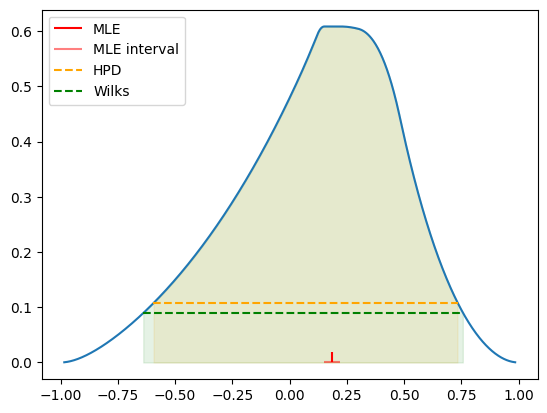

In [ ]:
x = inference.grid_result_by_size[size].grid
y = inference.grid_result_by_size[size].elr_on_grid
plt.plot(x, y)

mle = inference.mle_result_by_size[size].difference.mle
mle_interval = inference.mle_result_by_size[size].difference.interval
max_log_elr = inference.mle_result_by_size[size].max_log_elr
plt.vlines(
    mle, ymin=0, ymax=0.03*np.exp(max_log_elr), 
    colors='red', 
    label='MLE', 
)
plt.hlines(
    0, xmin=mle_interval[0], xmax=mle_interval[1], 
    colors='red', alpha=0.5, 
    label="MLE interval", 
)

hpd_interval = inference.hpd_result_by_size[size].hpd_95.interval
hpd_elr_cutoff = inference.hpd_result_by_size[size].hpd_95.elr_cutoff
plt.hlines(
    hpd_elr_cutoff, xmin=hpd_interval[0], xmax=hpd_interval[1], 
    color='orange', linestyles='--', 
    label='HPD', 
)
plt.fill_between(
    x, y, 
    where=(x >= hpd_interval[0]) & (x <= hpd_interval[1]), 
    color='orange', alpha=0.1, 
)

wilks_interval = inference.wilks_result_by_size[size].wilks_95.interval
wilks_elr_cutoff = inference.wilks_result_by_size[size].wilks_95.elr_cutoff
plt.hlines(
    wilks_elr_cutoff, xmin=wilks_interval[0], xmax=wilks_interval[1], 
    color='green', linestyles='--', 
    label='Wilks',
)
plt.fill_between(
    x, y, 
    where=(x >= wilks_interval[0]) & (x <= wilks_interval[1]), 
    color='green', alpha=0.1, 
)

plt.legend()
plt.show()